# Cobertura vacinal: e como um ano incompleto vira uma falsa catástrofe

**A pergunta:** a cobertura vacinal brasileira caiu — isso é fato conhecido e
preocupante. Mas quanto da queda que aparece nos dados é queda de verdade e
quanto é arquivo incompleto? Este notebook responde às duas coisas: mede a
cobertura de verdade e ensina a não confundir uma com a outra.

**Fonte:** Programa Nacional de Imunizações (PNI/DATASUS).

**Tempo estimado:** 5 a 10 minutos.

**O que você leva daqui:** uma função que recusa anos incompletos antes de
você publicar um gráfico errado, o retrato da cobertura por município, e a
noção clara do que o PNI do DATASUS cobre — e até quando.

In [2]:
%pip install pysus==2.10.6 nest_asyncio duckdb -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import nest_asyncio
nest_asyncio.apply()

import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
con = duckdb.connect()

def mil(numero):
    "Número no padrão brasileiro: 1234567 vira 1.234.567."
    return f"{numero:,.0f}".replace(",", ".")

print("Ambiente pronto.")

Ambiente pronto.


## 1. O que você pode trocar

In [4]:
UF = "PR"
META = 95      # meta de cobertura, em %, para a maioria das vacinas do calendário

print(f"Estado analisado: {UF}")

Estado analisado: PR


## 2. Até quando vai o PNI aqui

Primeiro aviso, e ele economiza muita frustração: **o PNI no espelho do DATASUS
termina em 2019.** Depois disso, o registro de vacinação migrou para o novo
SI-PNI, que não é publicado por esse caminho. Pedir 2021 devolve uma lista
vazia, sem erro nem explicação.

In [5]:
from pysus import list_files, pni

catalogo = list_files(dataset="pni", state=UF)
catalogo["arquivo"] = [os.path.basename(str(n).replace("\\", "/"))
                       for n in catalogo["name"]]
catalogo["tipo"] = catalogo["arquivo"].str[:4].str.upper()
anos = sorted(int(a) for a in catalogo["year"].dropna().unique())

print(f"Anos disponíveis para {UF}: de {anos[0]} a {anos[-1]}")
print()
print("Dois arquivos por ano:")
print("  CPNI — cobertura: já traz doses, população-alvo e o percentual")
print("  DPNI — doses aplicadas, detalhadas por mês, faixa etária e dose")
print()
print(f"Teste: pedir um ano posterior ao último disponível...")
print(f"pni('{UF}', {anos[-1] + 2}) devolveu {len(pni(UF, anos[-1] + 2))} arquivos.")

Anos disponíveis para PR: de 1994 a 2026
Dois arquivos por ano:
  CPNI — cobertura: já traz doses, população-alvo e o percentual
  DPNI — doses aplicadas, detalhadas por mês, faixa etária e dose
Teste: pedir um ano posterior ao último disponível...


pni('PR', 2028) devolveu 0 arquivos.


## 3. A conferência que precede qualquer gráfico

Aqui está o ponto central do notebook.

O arquivo de doses tem uma coluna de mês. Um ano completo tem doze. Se tiver
menos, o total do ano fica proporcionalmente menor — e o gráfico de cobertura
despenca, parecendo colapso vacinal quando é só arquivo pela metade.

A confusão é fácil de cometer porque a queda **de verdade** também existe. É
justamente por isso que separar as duas coisas importa: sem essa conferência,
não dá para saber qual parte da queda é real.

In [6]:
def meses_publicados(uf, ano):
    """Quantos meses de doses o ano tem, e o total de doses.

    Devolve (meses, doses). Um ano completo tem 12 meses.
    """
    caminhos = pni(uf, ano)
    doses = [c for c in caminhos
             if os.path.basename(c).upper().startswith("DPNI")]
    if not doses:
        return 0, 0
    caminho = doses[0].replace("\\", "/")
    resultado = con.execute(f"""
        SELECT count(DISTINCT MES) AS meses,
               sum(TRY_CAST(QT_DOSE AS BIGINT)) AS doses
        FROM read_parquet('{caminho}')
    """).df().iloc[0]
    return int(resultado["meses"]), int(resultado["doses"])

print(f"{'ano':>5} {'meses':>6} {'doses aplicadas':>18}   situação")
integridade = {}
for ano in anos[-12:]:
    meses, doses = meses_publicados(UF, ano)
    completo = meses == 12
    integridade[ano] = completo
    selo = "completo" if completo else f"INCOMPLETO — só {meses} meses"
    print(f"{ano:>5} {meses:>6} {mil(doses):>18}   {selo}")

ano  meses    doses aplicadas   situação


2010     12          7.492.683   completo


2011     12          5.769.367   completo


2012     12          7.244.301   completo


2013     12         10.767.980   completo


...

2017     12          5.389.664   completo


2018     12          6.543.817   completo


2019      5          2.744.114   INCOMPLETO — só 5 meses


2025      0                  0   INCOMPLETO — só 0 meses


2026      0                  0   INCOMPLETO — só 0 meses


Ali está. O último ano da série é o mais tentador de usar — e é o que está pela
metade. Quem pegasse o ano mais recente por reflexo publicaria uma queda de
cobertura que não aconteceu daquele tamanho.

A regra que fica: **em base com competência mensal, conte os meses antes de
somar o ano.**

In [7]:
completos = [a for a, ok in integridade.items() if ok]
ANO = completos[-1]
print(f"Anos completos disponíveis: {completos}")
print(f"Ano escolhido para a análise: {ANO}")

Anos completos disponíveis: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
Ano escolhido para a análise: 2018


## 4. A cobertura, município a município

O arquivo CPNI já traz o cálculo pronto: doses aplicadas, população-alvo e o
percentual. Cada linha é um município e um imunobiológico.

In [8]:
def cobertura(uf, ano):
    "Tabela de cobertura por município e imunobiológico."
    caminho = [c for c in pni(uf, ano)
               if os.path.basename(c).upper().startswith("CPNI")][0].replace("\\", "/")
    tabela = con.execute(f"""
        SELECT MUNIC AS municipio, IMUNO AS imuno,
               TRY_CAST(QT_DOSE AS BIGINT) AS doses,
               TRY_CAST(POP AS BIGINT) AS populacao,
               TRY_CAST(COBERT AS DOUBLE) AS cobertura
        FROM read_parquet('{caminho}')
        WHERE IMUNO IS NOT NULL AND IMUNO <> ''
    """).df()
    return tabela

tabela = cobertura(UF, ANO)
print(f"{mil(len(tabela))} linhas: "
      f"{tabela['municipio'].nunique()} municípios x "
      f"{tabela['imuno'].nunique()} imunobiológicos\n")

por_imuno = (
    tabela.groupby("imuno")
    .agg(**{"Doses": ("doses", "sum"), "População-alvo": ("populacao", "sum"),
            "Municípios": ("municipio", "nunique")})
)
por_imuno["Cobertura (%)"] = (
    por_imuno["Doses"] / por_imuno["População-alvo"] * 100).round(1)
por_imuno = por_imuno.dropna(subset=["Cobertura (%)"]).sort_values("Cobertura (%)")

print("Cobertura estadual de cada imunobiológico\n")
por_imuno

9.255 linhas: 399 municípios x 27 imunobiológicos
Cobertura estadual de cada imunobiológico


,Doses,População-alvo,Municípios,Cobertura (%)
imuno,,,,
010,7,6513,4,0.1
100,67,61161,30,0.1
059,17,4466,4,0.4
026,531,116931,132,0.5
102,4706,278424,307,1.7
094,68057,155040,399,43.9
097,97301,155040,399,62.8
095,98401,155040,399,63.5
099,98809,155040,399,63.7


Duas ressalvas antes de ler essa tabela.

A primeira: **o arquivo traz o código do imunobiológico, não o nome.** A tabela
que traduz `021` em "tríplice viral" não acompanha o dado e muda ao longo dos
anos. Este notebook não inventa os nomes — quem precisar identificá-los deve
consultar a documentação do PNI no DATASUS para o ano em questão.

A segunda salta aos olhos na tabela: alguns códigos aparecem com cobertura
quase zero, presentes em poucos municípios. Não são vacinas que ninguém tomou —
são **campanhas e imunobiológicos sem população-alvo definida**, em que o
denominador não faz sentido. Misturá-los com as vacinas do calendário afunda a
média e produz um diagnóstico falso. Ficam de fora.

Imunobiológicos de calendário: 21
Descartados (campanha ou sem população-alvo): 6 — códigos ['010', '100', '059', '026', '102', '103']
Abaixo da meta de 95%: 20 de 21


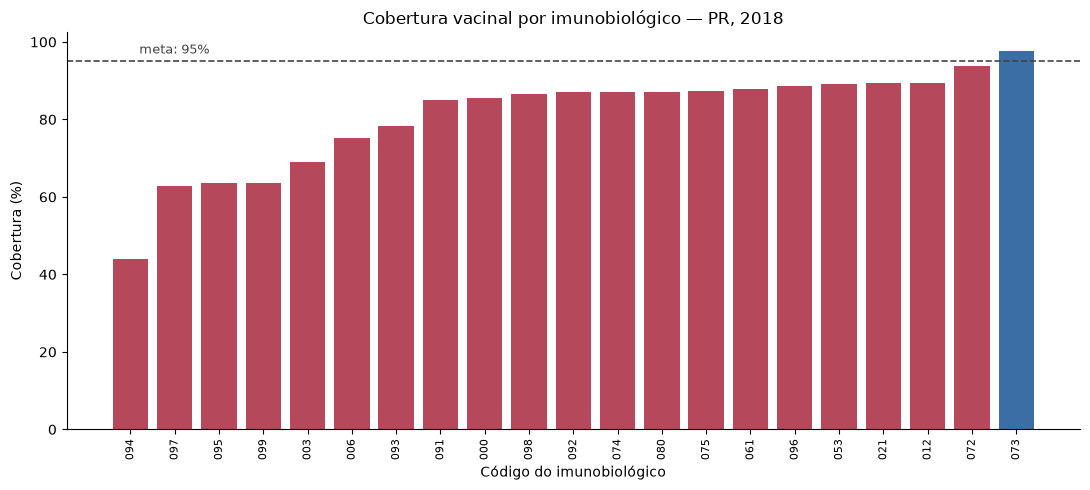

In [9]:
# Só as vacinas de calendário: as que têm população-alvo em todo o estado e
# cobertura dentro de uma faixa plausível.
calendario = por_imuno[
    (por_imuno["Cobertura (%)"] >= 5)
    & (por_imuno["Cobertura (%)"] <= 200)
    & (por_imuno["Municípios"] > por_imuno["Municípios"].max() * 0.9)
]
descartados = por_imuno.drop(calendario.index)

print(f"Imunobiológicos de calendário: {len(calendario)}")
print(f"Descartados (campanha ou sem população-alvo): {len(descartados)} — "
      f"códigos {list(descartados.index)}")
print()
abaixo = (calendario["Cobertura (%)"] < META).sum()
print(f"Abaixo da meta de {META}%: {abaixo} de {len(calendario)}")

figura, eixo = plt.subplots(figsize=(11, 5))
cores = ["#b5495b" if v < META else "#3b6ea5" for v in calendario["Cobertura (%)"]]
eixo.bar(calendario.index, calendario["Cobertura (%)"], color=cores)
eixo.axhline(META, color="#444", linestyle="--", linewidth=1.2)
eixo.text(0.2, META + 2, f"meta: {META}%", fontsize=9, color="#444")
eixo.set_ylabel("Cobertura (%)")
eixo.set_xlabel("Código do imunobiológico")
eixo.set_title(f"Cobertura vacinal por imunobiológico — {UF}, {ANO}", fontsize=12)
eixo.tick_params(axis="x", rotation=90, labelsize=8)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 5. A desigualdade dentro do estado

A média estadual esconde o essencial. Um estado com 95% de cobertura pode ter
dezenas de municípios em 60% — e é lá que o sarampo volta.

Uma observação de método: o arquivo traz uma coluna de cobertura já calculada,
mas no nível municipal ela vem fora de escala em boa parte dos registros. Como
temos as doses e a população-alvo, calculamos a cobertura nós mesmos — assim a
conta é a mesma do resto do notebook e dá para conferir de onde veio.

Imunobiológico com mais doses entre os de calendário: código 073
Municípios com população-alvo informada: 399
Cobertura mediana:              100.5%
Municípios abaixo da meta:      153 (38%)
Municípios abaixo de 50%:       2


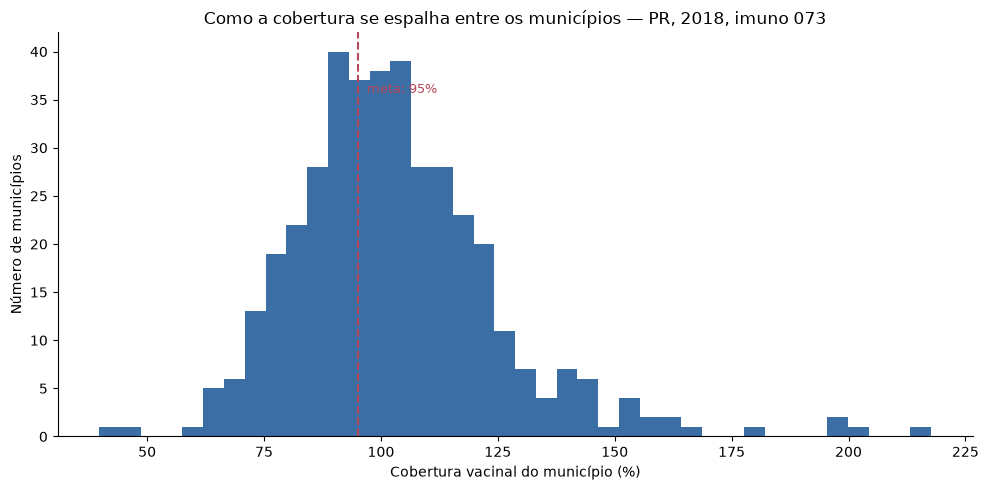

In [10]:
principal = calendario.nlargest(1, "Doses").index[0]

# Calculamos a cobertura em vez de usar o campo pronto: no nível municipal, o
# COBERT do arquivo traz valores fora de escala em boa parte dos municípios.
recorte = tabela[(tabela["imuno"] == principal)
                 & tabela["populacao"].notna() & (tabela["populacao"] > 0)].copy()
recorte["cobertura_calculada"] = recorte["doses"] / recorte["populacao"] * 100
recorte = recorte[recorte["cobertura_calculada"] <= 300]

print(f"Imunobiológico com mais doses entre os de calendário: código {principal}")
print(f"Municípios com população-alvo informada: {len(recorte)}\n")
print(f"Cobertura mediana:              {recorte['cobertura_calculada'].median():.1f}%")
print(f"Municípios abaixo da meta:      "
      f"{(recorte['cobertura_calculada'] < META).sum()} "
      f"({(recorte['cobertura_calculada'] < META).mean() * 100:.0f}%)")
print(f"Municípios abaixo de 50%:       {(recorte['cobertura_calculada'] < 50).sum()}")

figura, eixo = plt.subplots(figsize=(10, 5))
eixo.hist(recorte["cobertura_calculada"], bins=40, color="#3b6ea5")
eixo.axvline(META, color="#b5495b", linestyle="--", linewidth=1.5)
eixo.text(META + 2, eixo.get_ylim()[1] * 0.85, f"meta: {META}%",
          color="#b5495b", fontsize=9)
eixo.set_xlabel("Cobertura vacinal do município (%)")
eixo.set_ylabel("Número de municípios")
eixo.set_title(f"Como a cobertura se espalha entre os municípios — "
               f"{UF}, {ANO}, imuno {principal}", fontsize=12)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. A série no tempo, só com anos completos

Agora sim a comparação entre anos — usando apenas os anos que passaram na
conferência. É esta a curva que se pode publicar.

In [11]:
serie = []
for ano in completos:
    dados = cobertura(UF, ano)
    dados = dados[dados["populacao"].notna() & (dados["populacao"] > 0)]
    por_ano = dados.groupby("imuno").agg(doses=("doses", "sum"),
                                         populacao=("populacao", "sum"))
    por_ano["cob"] = por_ano["doses"] / por_ano["populacao"] * 100
    validos = por_ano[(por_ano["cob"] > 5) & (por_ano["cob"] < 200)]
    serie.append({
        "Ano": ano,
        "Imunos analisados": len(validos),
        "Cobertura mediana (%)": round(validos["cob"].median(), 1),
        "Abaixo da meta (%)": round((validos["cob"] < META).mean() * 100, 1),
    })

historico = pd.DataFrame(serie)
historico

,Ano,Imunos analisados,Cobertura mediana (%),Abaixo da meta (%)
0,2010,19,97.8,36.8
1,2011,16,103.0,18.8
2,2012,17,99.9,35.3
3,2013,20,100.3,40.0
4,2014,22,94.0,54.5
5,2015,23,97.4,47.8
6,2016,30,75.5,90.0
7,2017,21,88.2,90.5
8,2018,21,87.1,95.2


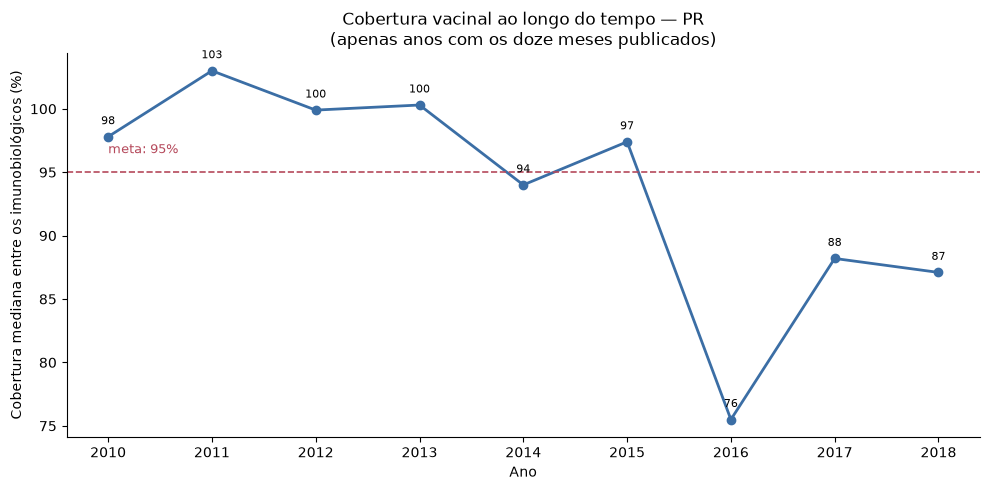

Anos descartados por estarem incompletos: [2019, 2025, 2026]


In [12]:
figura, eixo = plt.subplots(figsize=(10, 5))
eixo.plot(historico["Ano"], historico["Cobertura mediana (%)"],
          marker="o", color="#3b6ea5", linewidth=2)
eixo.axhline(META, color="#b5495b", linestyle="--", linewidth=1.2)
eixo.text(historico["Ano"].iloc[0], META + 1.5, f"meta: {META}%",
          color="#b5495b", fontsize=9)

for _, linha in historico.iterrows():
    eixo.annotate(f"{linha['Cobertura mediana (%)']:.0f}",
                  (linha["Ano"], linha["Cobertura mediana (%)"]),
                  textcoords="offset points", xytext=(0, 9),
                  ha="center", fontsize=8)

eixo.set_ylabel("Cobertura mediana entre os imunobiológicos (%)")
eixo.set_xlabel("Ano")
eixo.set_title(f"Cobertura vacinal ao longo do tempo — {UF}\n"
               f"(apenas anos com os doze meses publicados)", fontsize=12)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("Anos descartados por estarem incompletos: "
      f"{[a for a, ok in integridade.items() if not ok]}")

## 7. Conferindo com a realidade

In [13]:
print("Verificações de sanidade\n")
print(f"1. Cobertura mediana entre 60% e 110%?      "
      f"{historico['Cobertura mediana (%)'].iloc[-1]:.1f}% "
      f"({'sim' if 60 < historico['Cobertura mediana (%)'].iloc[-1] < 110 else 'ATENÇÃO'})")
print(f"2. Todos os municípios do estado presentes?  "
      f"{tabela['municipio'].nunique()} "
      f"({'sim' if tabela['municipio'].nunique() > 350 else 'ATENÇÃO'})")
print(f"3. Anos incompletos foram descartados?       "
      f"{'sim' if not all(integridade.values()) else 'nenhum era incompleto'}")
print()
print("Sobre a queda real: a cobertura vacinal brasileira caiu de fato a partir")
print("de meados da década de 2010, e o sarampo voltou a circular no país em")
print("2018 depois de anos eliminado. O que este notebook garante é que a queda")
print("medida aqui é a queda que existiu — e não o efeito de um arquivo pela")
print("metade.")

Verificações de sanidade
1. Cobertura mediana entre 60% e 110%?      87.1% (sim)
2. Todos os municípios do estado presentes?  399 (sim)
3. Anos incompletos foram descartados?       sim
Sobre a queda real: a cobertura vacinal brasileira caiu de fato a partir
de meados da década de 2010, e o sarampo voltou a circular no país em
2018 depois de anos eliminado. O que este notebook garante é que a queda
medida aqui é a queda que existiu — e não o efeito de um arquivo pela
metade.


## 8. Como adaptar

| Você quer | Mude isto |
|---|---|
| Outro estado | `UF = "AM"` |
| Doses por mês e faixa etária | use o arquivo `DPNI`, que tem `MES`, `FX_ETARIA` e `DOSE` |
| Uma vacina específica | filtre `imuno` — consultando antes a legenda do PNI para o ano |
| Comparar estados | rode em laço e junte as tabelas de cobertura |
| Dados a partir de 2020 | não estão aqui: o registro migrou para o novo SI-PNI |

### O que vale levar

`meses_publicados(uf, ano)` — a conferência que separa queda real de arquivo
incompleto. O mesmo raciocínio vale para SIH, SIA, CNES e CIHA, todos com
competência mensal: **conte os meses antes de somar o ano.**

---

*Exemplo do repositório [PySusNoCode-Exemplos](https://github.com/cartaproale/PySusNoCode-Exemplos).
Dados: PNI/DATASUS, via biblioteca [PySUS](https://github.com/AlertaDengue/PySUS).
Notebook executado de verdade antes de publicado.*